In [5]:
# ── Section 0: Imports & Config ──────────────────────────────────────────────
import json, os, re
from pathlib import Path

import jsonlines
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import warnings

In [2]:

# ── Paths ────────────────────────────────────────────────────────────────────
DATASET_PATH   = "sample-1M.jsonl"
NER_OUT_PATH   = "ner_results.jsonl"        # one JSON line per article
PROGRESS_PATH  = "ner_progress.json"        # set of completed article IDs
CSV_OUT_PATH = "ner_results.csv"

# ── Section 0 config: add EL tracking paths ───────────────────────────────────
EL_OUT_PATH       = "entity_linking_results.jsonl"
EL_PROGRESS_PATH  = "el_progress.json"   # tracks which norm_text+label pairs are done
EL_CSV_PATH       = "entity_linking_results.csv"

# ── GLiNER labels ────────────────────────────────────────────────────────────
LABELS = [
    "person", "norp", "facility", "organization", "gpe", "location",
    "product", "event", "work_of_art", "law", "language",
    "date", "time", "percent", "money", "quantity", "ordinal", "cardinal",

    
    "religion", "political_party", "nationality", "ethnic_group",
    "title", "award", "disease", "chemical", "weapon",
    "vehicle", "currency", "brand"
]

# ── Chunking ─────────────────────────────────────────────────────────────────
# GLiNER ~380 subword tokens ≈ ~280 words safely
# ── Section 0 config update ───────────────────────────────────────────────────
GLINER_MAX_TOKENS    = 380   # lowered from 380 to absorb GLiNER's internal specials
GLINER_STRIDE_TOKENS = 60
WARNINGS_PATH        = "ner_warnings.json"   # NEW: articles that triggered truncation

GLINER_THRESHOLD  = 0.4   # entity confidence threshold

In [3]:
# ── Section 1: Load Models ────────────────────────────────────────────────────
from gliner import GLiNER
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# GLiNER
print("Loading GLiNER …")
gliner_model = GLiNER.from_pretrained("urchade/gliner_mediumv2.1")
gliner_model.to(DEVICE)

# GENRE  — facebook/genre-linking-aidayago2 is the standard EL checkpoint
# It links to Wikipedia titles given [START_ENT] … [END_ENT] context
print("Loading GENRE …")
GENRE_MODEL_NAME = "facebook/genre-linking-aidayago2"
genre_tokenizer  = AutoTokenizer.from_pretrained(GENRE_MODEL_NAME)
genre_model      = AutoModelForSeq2SeqLM.from_pretrained(GENRE_MODEL_NAME)
genre_model.to(DEVICE)
genre_model.eval()
print("Models ready.")

Using device: cpu
Loading GLiNER …


/Users/punreachrany/Desktop/University of Alberta/Knowledge Graph/long-tail-entities-news/kg/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:190: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading GENRE …


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Models ready.


In [7]:
# ── Section 2: GLiNER helpers ─────────────────────────────────────────────────

# ── Section 2: replace split_into_chunks with a token-aware version ───────────

def split_into_chunks(text: str) -> list[tuple[str, int]]:
    """
    Splits *text* into overlapping chunks that each stay within
    GLINER_MAX_TOKENS subword tokens — using GLiNER's own tokenizer
    so the count is exact and no truncation warnings fire.

    Returns list of (chunk_text, char_offset_in_original).
    """
    tokenizer = gliner_model.data_processor.transformer_tokenizer

    # Encode the whole document once to get the token↔char mapping
    encoding = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=False,   # GLiNER adds its own specials
        truncation=False,
    )

    tokens         = encoding["input_ids"]
    offset_mapping = encoding["offset_mapping"]   # (char_start, char_end) per token
    total_tokens   = len(tokens)

    chunks = []
    i = 0
    while i < total_tokens:
        end = min(i + GLINER_MAX_TOKENS, total_tokens)

        # Char span that covers tokens[i:end]
        char_start = offset_mapping[i][0]
        char_end   = offset_mapping[end - 1][1]
        chunk_text = text[char_start:char_end]

        chunks.append((chunk_text, char_start))

        if end == total_tokens:
            break
        i += GLINER_MAX_TOKENS - GLINER_STRIDE_TOKENS   # slide forward with stride

    return chunks


def resolve_overlaps(entities: list[dict]) -> list[dict]:
    """
    When entity A's span is fully contained within entity B's span,
    keep B (the longer / more specific mention) and discard A.
    Example: 'Alberta' inside 'University of Alberta' → keep the latter.
    """
    # Sort by span length descending so longer spans are checked first
    sorted_ents = sorted(entities, key=lambda e: e["end"] - e["start"], reverse=True)
    kept = []
    for cand in sorted_ents:
        dominated = any(
            (k["start"] <= cand["start"] and k["end"] >= cand["end"]
             and not (k["start"] == cand["start"] and k["end"] == cand["end"]))
            for k in kept
        )
        if not dominated:
            kept.append(cand)
    return kept


def run_gliner_on_text(text: str) -> list[dict]:
    """
    Runs GLiNER on *text* with chunking, remaps offsets to the full document,
    resolves overlapping spans, and returns a deduplicated entity list.
    Each entity dict: {text, label, start, end, score}
    """
    chunks   = split_into_chunks(text)
    all_ents = []

    for chunk_text, char_offset in chunks:
        preds = gliner_model.predict_entities(
            chunk_text, LABELS, threshold=GLINER_THRESHOLD
        )
        for ent in preds:
            all_ents.append({
                "text":  ent["text"],
                "label": ent["label"],
                "start": ent["start"] + char_offset,   # remap to doc offset
                "end":   ent["end"]   + char_offset,
                "score": round(ent["score"], 4),
            })

    # Remove span-level duplicates from chunk overlaps
    seen = set()
    unique_ents = []
    for e in all_ents:
        key = (e["start"], e["end"], e["label"])
        if key not in seen:
            seen.add(key)
            unique_ents.append(e)

    return resolve_overlaps(unique_ents)

In [ ]:
# ── Section 3: NER with progress tracking + warning capture ──────────────────
def load_progress() -> set:
    if Path(PROGRESS_PATH).exists():
        with open(PROGRESS_PATH) as f:
            return set(json.load(f))
    return set()

def save_progress(done_ids: set):
    with open(PROGRESS_PATH, "w") as f:
        json.dump(list(done_ids), f)

def load_warned_ids() -> set:
    if Path(WARNINGS_PATH).exists():
        with open(WARNINGS_PATH) as f:
            return set(json.load(f))
    return set()

def save_warned_ids(warned_ids: set):
    with open(WARNINGS_PATH, "w") as f:
        json.dump(list(warned_ids), f)


def run_gliner_on_text_safe(text: str) -> tuple[list[dict], bool]:
    """
    Wraps run_gliner_on_text with warning capture.
    Returns (entities, was_truncated).
    was_truncated=True means a truncation warning fired during processing.
    """
    triggered = []

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        entities = run_gliner_on_text(text)

    truncation_warnings = [
        w for w in caught
        if issubclass(w.category, UserWarning)
        and "truncated" in str(w.message).lower()
    ]

    return entities, len(truncation_warnings) > 0


def run_ner_pipeline(max_articles: int | None = None):
    """
    Streams through the dataset, skips already-processed IDs,
    writes NER results line-by-line to NER_OUT_PATH.
    Articles that trigger GLiNER truncation warnings are logged to
    WARNINGS_PATH and excluded from the results file.
    Safe to interrupt and resume at any time.
    """
    done_ids   = load_progress()
    warned_ids = load_warned_ids()
    print(f"Resuming  : {len(done_ids)} articles already processed.")
    print(f"Warned IDs: {len(warned_ids)} articles previously flagged & skipped.")

    with jsonlines.open(DATASET_PATH) as reader:
        total = sum(1 for _ in reader)

    processed    = 0
    new_warnings = 0

    with jsonlines.open(DATASET_PATH) as reader, \
         jsonlines.open(NER_OUT_PATH, mode="a") as writer:

        for article in tqdm(reader, total=total, desc="NER"):
            art_id = article["id"]

            if art_id in done_ids:
                continue

            full_text = (article.get("title") or "") + " " + \
                        (article.get("content") or "")
            full_text = full_text.strip()

            if not full_text:
                done_ids.add(art_id)
                continue

            entities, was_truncated = run_gliner_on_text_safe(full_text)

            if was_truncated:
                # Log it, mark as done so we don't retry it, but don't write results
                warned_ids.add(art_id)
                done_ids.add(art_id)
                new_warnings += 1
            else:
                writer.write({"id": art_id, "entities": entities})
                done_ids.add(art_id)

            processed += 1

            if processed % 100 == 0:
                save_progress(done_ids)
                save_warned_ids(warned_ids)
                print(f"  [{processed}] warnings this run: {new_warnings}")

            if max_articles and processed >= max_articles:
                print(f"Stopped early after {processed} articles.")
                break

    save_progress(done_ids)
    save_warned_ids(warned_ids)
    print(f"\nDone. Processed: {processed} | Truncation-warned (excluded): {new_warnings}")
    print(f"Warning IDs saved to: {WARNINGS_PATH}")


run_ner_pipeline(max_articles=None)

In [8]:
# ── Section 4: Deduplicate NER results ───────────────────────────────────────
# Dedup key = (normalized_surface_form, entity_type)
# We keep the highest-confidence occurrence of each unique (text, label) pair.

def load_ner_results(path: str = NER_OUT_PATH) -> list[dict]:
    results = []
    with jsonlines.open(path) as reader:
        for row in reader:
            results.append(row)
    return results


def build_dedup_entity_table(ner_results: list[dict]) -> pd.DataFrame:
    """
    Flatten all entities across all articles into one DataFrame,
    then deduplicate on (normalized_text, label).
    Returns the deduplicated DataFrame ready for entity linking.
    """
    rows = []
    for record in ner_results:
        art_id = record["id"]
        for ent in record["entities"]:
            rows.append({
                "article_id":  art_id,
                "text":        ent["text"],
                "norm_text":   ent["text"].strip().lower(),
                "label":       ent["label"],
                "start":       ent["start"],
                "end":         ent["end"],
                "score":       ent["score"],
            })

    df = pd.DataFrame(rows)

    # Keep the highest-score row per (norm_text, label) pair
    df_dedup = (
        df.sort_values("score", ascending=False)
          .drop_duplicates(subset=["norm_text", "label"])
          .reset_index(drop=True)
    )

    print(f"Total entity mentions : {len(df):,}")
    print(f"Unique (text, type)   : {len(df_dedup):,}")
    return df_dedup


ner_results = load_ner_results()
entity_df   = build_dedup_entity_table(ner_results)
entity_df.head(50)

Total entity mentions : 8,499,579
Unique (text, type)   : 1,722,591


,article_id,text,norm_text,label,start,end,score
0,043c3bbc-746a-4f3a-9967-d5bc62ceda34,gout,gout,disease,424,428,0.9981
1,43559af7-d09a-40a4-a7b2-3b82654e829c,Calvin Klein,calvin klein,brand,293,305,0.9980
2,23ab00fe-74fa-4c03-9558-52692e9d07e2,Burning Man,burning man,event,162,173,0.9978
3,89ad3773-189a-4c6f-bdc4-916533d8ca15,zara,zara,brand,241,245,0.9978
4,e092bc17-fb87-4cb1-af61-7672b2e9697c,Lyme Disease,lyme disease,disease,221,233,0.9978
5,1d07f3c0-51f7-4bcc-9b8a-772db958f524,Gaucher disease,gaucher disease,disease,3123,3138,0.9975
6,698434fa-c2d8-486a-b6dc-9754504999fd,Wounded Warrior Project,wounded warrior project,organization,127,150,0.9975
7,63192b2a-08cf-4645-969f-c87604a9a226,Aston Martin,aston martin,brand,25,37,0.9975
8,3a9f75fb-b854-4dac-a7e2-e7b752a63513,Gaelic,gaelic,language,1768,1774,0.9974
9,35bdaf75-aa95-4807-a4b0-6e0db5e28e0e,Zoya,zoya,brand,373,377,0.9974


In [13]:
# ── Section 5: Entity Linking with GENRE (resumable, saves per batch) ─────────

GENRE_BATCH_SIZE = 16
GENRE_NUM_BEAMS  = 5


def build_genre_input(surface: str, context: str = "") -> str:
    if context:
        idx = context.lower().find(surface.lower())
        if idx != -1:
            prefix = context[max(0, idx - 100): idx]
            suffix = context[idx + len(surface): idx + len(surface) + 100]
            return f"{prefix} [START_ENT] {surface} [END_ENT] {suffix}"
    return f"[START_ENT] {surface} [END_ENT]"


def genre_link_batch(surfaces: list[str],
                     contexts: list[str] | None = None) -> list[str]:
    if contexts is None:
        contexts = [""] * len(surfaces)

    inputs_text = [build_genre_input(s, c) for s, c in zip(surfaces, contexts)]
    inputs = genre_tokenizer(
        inputs_text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    ).to(DEVICE)

    with torch.no_grad():
        outputs = genre_model.generate(
            **inputs,
            num_beams=GENRE_NUM_BEAMS,
            num_return_sequences=1,
            max_length=64,
        )
    return genre_tokenizer.batch_decode(outputs, skip_special_tokens=True)


# ── Progress helpers ──────────────────────────────────────────────────────────

def el_progress_key(norm_text: str, label: str) -> str:
    """Unique key for each (entity, type) pair."""
    return f"{norm_text}||{label}"


def load_el_progress() -> set:
    """Returns set of already-linked keys."""
    if Path(EL_PROGRESS_PATH).exists():
        with open(EL_PROGRESS_PATH) as f:
            return set(json.load(f))
    return set()


def save_el_progress(done_keys: set):
    with open(EL_PROGRESS_PATH, "w") as f:
        json.dump(list(done_keys), f)


# ── Main EL pipeline ──────────────────────────────────────────────────────────

def run_entity_linking(df: pd.DataFrame, limit: int | None = None):
    """
    Links entities to Wikipedia titles via GENRE.
    - Skips already-linked (norm_text, label) pairs using EL_PROGRESS_PATH
    - Appends each batch result immediately to EL_OUT_PATH (JSONL)
    - Safe to interrupt and resume at any time
    - Set limit=N for testing (e.g. limit=10)
    """
    if limit is not None:
        df = df.head(limit).copy()
    else:
        df = df.copy()

    done_keys = load_el_progress()
    print(f"Resuming EL: {len(done_keys)} entities already linked.")

    # Filter to only unprocessed rows
    df["_el_key"] = df.apply(
        lambda r: el_progress_key(r["norm_text"], r["label"]), axis=1
    )
    pending_df = df[~df["_el_key"].isin(done_keys)].reset_index(drop=True)
    print(f"Pending: {len(pending_df):,} entities to link.")

    if pending_df.empty:
        print("Nothing to do — all entities already linked.")
        return

    new_linked = 0

    with jsonlines.open(EL_OUT_PATH, mode="a") as writer:
        for i in tqdm(range(0, len(pending_df), GENRE_BATCH_SIZE), desc="GENRE linking"):
            batch_df = pending_df.iloc[i: i + GENRE_BATCH_SIZE]
            surfaces = batch_df["text"].tolist()
            preds    = genre_link_batch(surfaces)

            for (_, row), wiki_title in zip(batch_df.iterrows(), preds):
                record = {
                    "article_id": row["article_id"],
                    "text":       row["text"],
                    "norm_text":  row["norm_text"],
                    "label":      row["label"],
                    "score":      row["score"],
                    "wiki_title": wiki_title,
                }
                writer.write(record)
                done_keys.add(row["_el_key"])
                new_linked += 1

            # Flush progress after every batch
            save_el_progress(done_keys)

    print(f"\nDone. Linked this run: {new_linked:,}")
    print(f"  JSONL → {EL_OUT_PATH}")
    print(f"  Progress → {EL_PROGRESS_PATH}")


# ── Run ───────────────────────────────────────────────────────────────────────
# run_entity_linking(entity_df)             # full run
run_entity_linking(entity_df, limit=50) # test on 10

Resuming EL: 0 entities already linked.
Pending: 50 entities to link.


GENRE linking:   0%|          | 0/4 [00:00<?, ?it/s]


Done. Linked this run: 50
  JSONL → entity_linking_results.jsonl
  Progress → el_progress.json


In [14]:
# ── Section 6: Convert JSONL results → CSV ────────────────────────────────────

def export_el_csv():
    """
    Reads the completed EL JSONL and writes a clean CSV.
    Run this whenever you want a snapshot — does not affect the JSONL or progress.
    """
    if not Path(EL_OUT_PATH).exists():
        print(f"No results file found at {EL_OUT_PATH}. Run entity linking first.")
        return

    rows = []
    with jsonlines.open(EL_OUT_PATH) as reader:
        for row in reader:
            rows.append(row)

    if not rows:
        print("Results file is empty.")
        return

    el_df = pd.DataFrame(rows)
    el_df.to_csv(EL_CSV_PATH, index=False)

    print(f"Exported {len(el_df):,} rows → {EL_CSV_PATH}")
    print("\nTop entity types:")
    print(el_df["label"].value_counts().head(15).to_string())
    return el_df


el_df = export_el_csv()
el_df.head(10)

Exported 50 rows → entity_linking_results.csv

Top entity types:
label
brand              22
disease            14
organization        5
language            3
event               1
political_party     1
person              1
award               1
chemical            1
product             1


,article_id,text,norm_text,label,score,wiki_title
0,043c3bbc-746a-4f3a-9967-d5bc62ceda34,gout,gout,disease,0.9981,Gout
1,43559af7-d09a-40a4-a7b2-3b82654e829c,Calvin Klein,calvin klein,brand,0.9980,Calvin Klein
2,23ab00fe-74fa-4c03-9558-52692e9d07e2,Burning Man,burning man,event,0.9978,Burning Man
3,89ad3773-189a-4c6f-bdc4-916533d8ca15,zara,zara,brand,0.9978,Zara (retailer)
4,e092bc17-fb87-4cb1-af61-7672b2e9697c,Lyme Disease,lyme disease,disease,0.9978,Lyme disease
5,1d07f3c0-51f7-4bcc-9b8a-772db958f524,Gaucher disease,gaucher disease,disease,0.9975,Gaucher's disease
6,698434fa-c2d8-486a-b6dc-9754504999fd,Wounded Warrior Project,wounded warrior project,organization,0.9975,Wounded Warrior Project
7,63192b2a-08cf-4645-969f-c87604a9a226,Aston Martin,aston martin,brand,0.9975,Aston Martin
8,3a9f75fb-b854-4dac-a7e2-e7b752a63513,Gaelic,gaelic,language,0.9974,Goidelic languages
9,35bdaf75-aa95-4807-a4b0-6e0db5e28e0e,Zoya,zoya,brand,0.9974,Zoya (band)


In [23]:
merged_df = pd.merge(
    entity_df,
    el_df,
    on="article_id",
    how="inner",
    suffixes=("_orig", "_linked")
)

# merged_df[["article_id", "text_orig", "text_linked", "label_orig", "label_linked"]].head(50)

In [24]:
merged_df[["article_id", "text_orig", "text_linked", "label_orig", "label_linked"]].head(50)

,article_id,text_orig,text_linked,label_orig,label_linked
0,043c3bbc-746a-4f3a-9967-d5bc62ceda34,gout,gout,disease,disease
1,43559af7-d09a-40a4-a7b2-3b82654e829c,Calvin Klein,Calvin Klein,brand,brand
2,23ab00fe-74fa-4c03-9558-52692e9d07e2,Burning Man,Burning Man,event,event
3,89ad3773-189a-4c6f-bdc4-916533d8ca15,zara,zara,brand,brand
4,e092bc17-fb87-4cb1-af61-7672b2e9697c,Lyme Disease,Lyme Disease,disease,disease
5,1d07f3c0-51f7-4bcc-9b8a-772db958f524,Gaucher disease,Gaucher disease,disease,disease
6,698434fa-c2d8-486a-b6dc-9754504999fd,Wounded Warrior Project,Wounded Warrior Project,organization,organization
7,63192b2a-08cf-4645-969f-c87604a9a226,Aston Martin,Aston Martin,brand,brand
8,3a9f75fb-b854-4dac-a7e2-e7b752a63513,Gaelic,Gaelic,language,language
9,35bdaf75-aa95-4807-a4b0-6e0db5e28e0e,Zoya,Zoya,brand,brand


In [27]:
rows = []

with open(NER_OUT_PATH, "r") as f:
    for line in f:
        article = json.loads(line)
        article_id = article["id"]
        for ent in article["entities"]:
            rows.append({
                "id": article_id,
                "text": ent["text"],
                "label": ent["label"],
                "start": ent["start"],
                "end": ent["end"],
                "score": ent["score"]
            })

# Convert to DataFrame
df = pd.DataFrame(rows)

# Save as CSV
df.to_csv(CSV_OUT_PATH, index=False)

print(f"Saved CSV to {CSV_OUT_PATH}")

Saved CSV to ner_results.csv


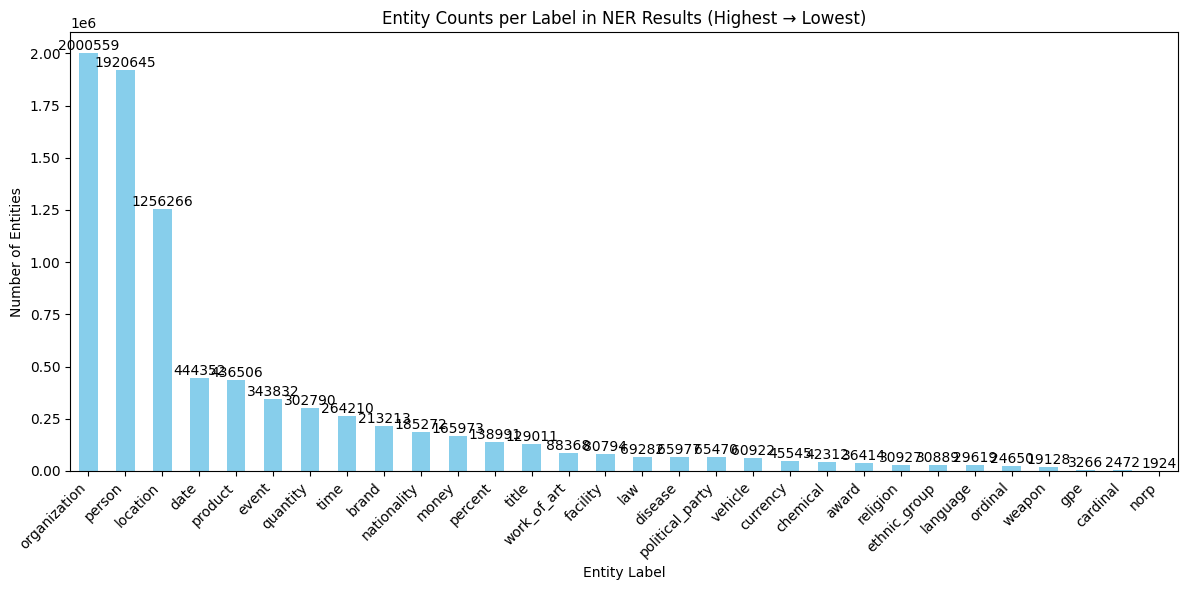

In [11]:


# Read CSV
df = pd.read_csv("ner_results.csv")

# Count the number of entities per label
label_counts = df['label'].value_counts().reindex(LABELS, fill_value=0)

# Sort descending
label_counts_sorted = label_counts.sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 6))
label_counts_sorted.plot(kind='bar', color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Entity Label")
plt.ylabel("Number of Entities")
plt.title("Entity Counts per Label in NER Results (Highest → Lowest)")
plt.tight_layout()
plt.show()

# ── Print Counts as Table ─────────────────────────────────
counts_table = pd.DataFrame({
    "Label": label_counts.index,
    "Count": label_counts.values
})

              Label    Count
0            person  1920645
1              norp     1924
2          facility    80794
3      organization  2000559
4               gpe     3266
5          location  1256266
6           product   436506
7             event   343832
8       work_of_art    88368
9               law    69282
10         language    29619
11             date   444352
12             time   264210
13          percent   138991
14            money   165973
15         quantity   302790
16          ordinal    24650
17         cardinal     2472
18         religion    30927
19  political_party    65470
20      nationality   185272
21     ethnic_group    30889
22            title   129011
23            award    36414
24          disease    65977
25         chemical    42312
26           weapon    19128
27          vehicle    60922
28         currency    45545
29            brand   213213


In [10]:
counts_table

,Label,Count
0,person,1920645
1,norp,1924
2,facility,80794
3,organization,2000559
4,gpe,3266
5,location,1256266
6,product,436506
7,event,343832
8,work_of_art,88368
9,law,69282
